# Support Vector Machine — No-Framework (Pure NumPy)

**Dataset:** MAGIC Gamma Telescope (UCI) — 18,905 samples, 10 features, binary classification  
**Task:** Classify cosmic ray observations as gamma rays (signal) or hadrons (background noise)  
**Algorithm:** SMO (Sequential Minimal Optimization) — Platt, 1998  
**Framework showcase:** Kernel Comparison — linear vs RBF vs polynomial

## SMO Algorithm Overview

SMO solves the SVM dual optimization problem by breaking it into the smallest possible sub-problems: optimizing **two** Lagrange multipliers (alphas) at a time while holding all others fixed.

**Why two at a time?** The equality constraint Σ(αᵢyᵢ) = 0 means changing one alpha alone would violate the constraint. Two is the minimum that can be updated while maintaining feasibility.

**Each SMO iteration:**
1. Select two alphas that violate KKT conditions (heuristic selection)
2. Compute the optimal update analytically (closed-form — no gradient descent needed)
3. Clip the updated alphas to stay within [0, C] box constraints
4. Update the bias term b

This is the same algorithm sklearn's `SVC` uses internally (via libsvm's C implementation). We implement it in pure Python/NumPy to understand the mechanics.

## Hyperparameters (from Scikit-Learn tuning)
- **Kernel**: Polynomial (degree=3, coef0=1)
- **C**: 10.0
- **gamma**: 1 / (n_features × X_train.var()) ≈ 'scale'

In [1]:
import numpy as np
import sys
import os
import pickle

# Add project root to path for shared utilities
sys.path.insert(0, os.path.abspath('../..'))

from utils.data_loader import load_processed_data
from utils.metrics import evaluate_classifier, print_metrics
from utils.performance import track_performance, track_inference, get_model_size
from utils.visualization import (plot_confusion_matrix, plot_roc_curve,
                                  plot_calibration_curve, plot_kernel_comparison,
                                  plot_svm_convergence)
from utils.results import save_results, add_result, print_comparison, build_results_dict
from utils.svm_utils import to_svm_labels, to_std_labels, platt_calibrate, platt_predict_proba

# Configuration — hyperparameters from Scikit-Learn tuning
RANDOM_STATE = 113
FRAMEWORK = 'No-Framework'
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

C = 10.0               # Regularization (from SK C sweep)
DEGREE = 3             # Polynomial degree (from SK kernel comparison)
COEF0 = 1              # Polynomial coef0
TOL = 1e-3             # SMO convergence tolerance
MAX_PASSES = 20        # Max consecutive passes without alpha changes

# Load preprocessed data
X_train, X_test, y_train, y_test, metadata = load_processed_data('svm')
feature_names = metadata['feature_names']

# Compute gamma = 'scale' (same as sklearn's default)
GAMMA = 1.0 / (X_train.shape[1] * X_train.var())

# Convert labels: {0, 1} → {-1, +1} for SVM math
y_train_svm = to_svm_labels(y_train)
y_test_svm = to_svm_labels(y_test)

print("=" * 60)
print("SUPPORT VECTOR MACHINE — NO-FRAMEWORK (SMO)")
print("=" * 60)
print(f"\nDataset: {metadata['dataset']}")
print(f"Features: {metadata['n_features']} (all continuous, StandardScaler applied)")
print(f"Training: {X_train.shape[0]:,} samples")
print(f"Test:     {X_test.shape[0]:,} samples")
print(f"Classes:  {metadata['class_names']}")
print(f"Labels:   {np.unique(y_train_svm)} (converted from {{0,1}} to {{-1,+1}})")
print(f"\nHyperparameters (from Scikit-Learn tuning):")
print(f"  C={C}, kernel=poly, degree={DEGREE}, coef0={COEF0}")
print(f"  gamma={GAMMA:.6f} (1 / (n_features * X.var()))")
print(f"  SMO: tol={TOL}, max_passes={MAX_PASSES}")

SUPPORT VECTOR MACHINE — NO-FRAMEWORK (SMO)

Dataset: MAGIC Gamma Telescope (UCI)
Features: 10 (all continuous, StandardScaler applied)
Training: 15,124 samples
Test:     3,781 samples
Classes:  ['hadron (background)', 'gamma (signal)']
Labels:   [-1  1] (converted from {0,1} to {-1,+1})

Hyperparameters (from Scikit-Learn tuning):
  C=10.0, kernel=poly, degree=3, coef0=1
  gamma=0.100000 (1 / (n_features * X.var()))
  SMO: tol=0.001, max_passes=20


In [2]:
# Step 1: Kernel Functions
print("=" * 60)
print("STEP 1: KERNEL FUNCTIONS")
print("=" * 60)

"""
Kernel functions compute the similarity between pairs of samples.
SVM uses these instead of raw dot products to implicitly map data
to higher-dimensional spaces where classes become linearly separable.

Each function takes two matrices and returns the kernel (Gram) matrix:
    K[i,j] = kernel(X[i], X[j])

For training: K is n_train x n_train (15,124 x 15,124 ≈ 900MB float64)
For prediction: K is n_test x n_train (3,781 x 15,124)
"""

def linear_kernel(X1, X2):
    """
    Linear kernel: K(x, z) = x^T z
    
    Simple dot product — no feature transformation.
    Finds a straight hyperplane boundary. Works when classes
    are linearly separable (they aren't here, as SK showed).
    
    Args:
        X1: (n1, d) array
        X2: (n2, d) array
    Returns:
        (n1, n2) kernel matrix
    """
    return X1 @ X2.T


def rbf_kernel(X1, X2, gamma):
    """
    RBF (Radial Basis Function) kernel: K(x, z) = exp(-gamma * ||x - z||^2)
    
    Maps to infinite-dimensional space. The most common non-linear kernel.
    gamma controls the "reach" of each training sample:
      - Large gamma: each sample influences only nearby points (risk overfitting)
      - Small gamma: each sample influences far-away points (risk underfitting)
    
    Args:
        X1: (n1, d) array
        X2: (n2, d) array
        gamma: RBF width parameter
    Returns:
        (n1, n2) kernel matrix
    """
    # ||x - z||^2 = ||x||^2 + ||z||^2 - 2 * x^T z
    # This avoids creating an (n1, n2, d) intermediate from broadcasting
    sq1 = np.sum(X1 ** 2, axis=1).reshape(-1, 1)  # (n1, 1)
    sq2 = np.sum(X2 ** 2, axis=1).reshape(1, -1)  # (1, n2)
    dist_sq = sq1 + sq2 - 2 * (X1 @ X2.T)        # (n1, n2)
    return np.exp(-gamma * dist_sq)


def poly_kernel(X1, X2, gamma, degree, coef0):
    """
    Polynomial kernel: K(x, z) = (gamma * x^T z + coef0)^degree
    
    Maps to a finite-dimensional space of polynomial features.
    degree=1 reduces to (scaled) linear. degree=3 captures cubic
    interactions between features without explicitly creating them.
    
    Args:
        X1: (n1, d) array
        X2: (n2, d) array
        gamma: scaling factor
        degree: polynomial degree
        coef0: independent term (allows non-homogeneous polynomials)
    Returns:
        (n1, n2) kernel matrix
    """
    return (gamma * (X1 @ X2.T) + coef0) ** degree


# Quick test: verify shapes and symmetry on small subset
print("\nQuick test on 100 samples...")
X_small = X_train[:100]

K_lin = linear_kernel(X_small, X_small)
K_rbf = rbf_kernel(X_small, X_small, GAMMA)
K_poly = poly_kernel(X_small, X_small, GAMMA, DEGREE, COEF0)

for name, K in [('Linear', K_lin), ('RBF', K_rbf), ('Poly', K_poly)]:
    is_symmetric = np.allclose(K, K.T)
    diag_check = K[0, 0]
    print(f"  {name:8s}: shape={K.shape}, symmetric={is_symmetric}, "
          f"K[0,0]={diag_check:.4f}")

# RBF diagonal should be 1.0 (distance to self = 0, exp(0) = 1)
print(f"\n  RBF K[0,0] = {K_rbf[0,0]:.6f} (should be 1.0)")
print(f"  RBF K[0,1] = {K_rbf[0,1]:.6f} (similarity between sample 0 and 1)")

# Memory estimate for full training kernel matrix
n = X_train.shape[0]
mem_gb = (n * n * 8) / (1024 ** 3)  # float64 = 8 bytes
print(f"\n  Full kernel matrix: {n} x {n} = {n*n:,} entries")
print(f"  Memory: {mem_gb:.2f} GB (float64)")

STEP 1: KERNEL FUNCTIONS

Quick test on 100 samples...
  Linear  : shape=(100, 100), symmetric=True, K[0,0]=5.3309
  RBF     : shape=(100, 100), symmetric=True, K[0,0]=1.0000
  Poly    : shape=(100, 100), symmetric=True, K[0,0]=3.6033

  RBF K[0,0] = 1.000000 (should be 1.0)
  RBF K[0,1] = 0.913836 (similarity between sample 0 and 1)

  Full kernel matrix: 15124 x 15124 = 228,735,376 entries
  Memory: 1.70 GB (float64)


In [3]:
# Step 4: Dual Gradient Descent + Predict
"""
Instead of SMO (optimizing 2 alphas at a time), we update ALL alphas
simultaneously via gradient ascent on the dual objective:

  maximize: L(α) = Σαᵢ - 0.5 * ΣΣ αᵢαⱼyᵢyⱼK(xᵢ,xⱼ)
  subject to: 0 ≤ αᵢ ≤ C,  Σαᵢyᵢ = 0

This is the same dual problem SMO solves, but gradient descent is
naturally vectorized — every alpha moves each iteration. No pair
selection heuristics, no convergence traps.

The gradient is: ∂L/∂α = 1 - y ⊙ K(α⊙y)
After each step, we project onto constraints (clip + equality fix).
"""

print("=" * 60)
print("STEP 2: DUAL GRADIENT DESCENT")
print("=" * 60)

def train_dual_svm(K, y, C, n_iters=3000, verbose=True):
    """
    Train SVM via projected gradient ascent on the dual objective.
    
    Each iteration:
    1. Compute gradient: ∂L/∂αⱼ = 1 - yⱼ·[K(α⊙y)]ⱼ
    2. Adaptive step size via quadratic line search on the dual
    3. Gradient ascent: α += lr * gradient
    4. Project: clip α to [0, C], then fix Σαy = 0
    
    Args:
        K: (n, n) precomputed kernel matrix
        y: (n,) labels in {-1, +1}
        C: regularization parameter
        n_iters: gradient ascent iterations
        verbose: print progress every 500 iterations
        
    Returns:
        alphas: (n,) optimized Lagrange multipliers
        b: scalar bias term
        objectives: dual objective per iteration (for convergence plot)
    """
    n = len(y)
    alphas = np.zeros(n)
    objectives = []
    
    for t in range(n_iters):
        # Current state vectors
        ay = alphas * y                    # α ⊙ y, shape (n,)
        Kay = K @ ay                       # K(α⊙y), the main O(n²) op
        
        # Dual objective: L = Σα - 0.5·(α⊙y)ᵀ K (α⊙y)
        obj = np.sum(alphas) - 0.5 * np.dot(ay, Kay)
        objectives.append(obj)
        
        # Gradient: ∂L/∂αⱼ = 1 - yⱼ · [K(α⊙y)]ⱼ
        grad = 1.0 - y * Kay
        
        # Adaptive learning rate via quadratic line search
        # For a quadratic objective, optimal lr = (gᵀg) / (gᵀQg)
        # where Q[i,j] = yᵢyⱼK[i,j]. We compute Qg without storing Q:
        # Qg = y ⊙ K(y ⊙ g)
        Qg = y * (K @ (y * grad))
        gTg = np.dot(grad, grad)
        gTQg = np.dot(grad, Qg)
        lr_t = gTg / (gTQg + 1e-12) if gTQg > 1e-12 else 1e-6
        
        # Gradient ascent step
        alphas = alphas + lr_t * grad
        
        # Project onto box constraint: 0 ≤ αᵢ ≤ C
        alphas = np.clip(alphas, 0, C)
        
        # Project onto equality constraint: Σαᵢyᵢ = 0
        # Alternating projection between box and hyperplane
        for _ in range(5):
            violation = np.sum(alphas * y)
            if abs(violation) < 1e-6:
                break
            alphas -= (violation / n) * y
            alphas = np.clip(alphas, 0, C)
        
        if verbose and t % 500 == 0:
            n_sv = np.sum(alphas > 1e-5)
            n_bound = np.sum(np.isclose(alphas, C, atol=1e-3))
            print(f"  Iter {t:5d}: obj={obj:.2f}, SVs={n_sv:,}, "
                  f"bound={n_bound:,}, lr={lr_t:.6f}")
    
    # Bias b from non-bound support vectors
    # Non-bound SVs (0 < α < C) satisfy: yᵢ = Σⱼ αⱼyⱼK(xⱼ,xᵢ) + b
    # So b = yᵢ - Σⱼ αⱼyⱼK(xⱼ,xᵢ), averaged for stability
    sv_nonbound = (alphas > 1e-5) & (alphas < C - 1e-5)
    ay = alphas * y
    if np.any(sv_nonbound):
        b = np.mean(y[sv_nonbound] - K[sv_nonbound] @ ay)
    else:
        sv_all = alphas > 1e-5
        b = np.mean(y[sv_all] - K[sv_all] @ ay) if np.any(sv_all) else 0.0
    
    if verbose:
        n_sv = np.sum(alphas > 1e-5)
        n_bound = np.sum(np.isclose(alphas, C, atol=1e-3))
        print(f"\n  Final: obj={objectives[-1]:.2f}")
        print(f"  Support vectors: {n_sv:,} / {n:,} ({100*n_sv/n:.1f}%)")
        print(f"  At bound (α=C): {n_bound:,}")
        print(f"  Bias b: {b:.4f}")
    
    return alphas, b, objectives


def predict_svm(X_new, X_train, y_train, alphas, b, kernel_fn, **kernel_params):
    """
    Predict using trained SVM.
    
    f(x) = Σ(αᵢyᵢK(xᵢ, x)) + b
    Only support vectors (α > 0) contribute.
    
    Returns:
        predictions: (m,) in {-1, +1}
        decision_values: (m,) raw f(x) for Platt calibration
    """
    sv_mask = alphas > 1e-5
    sv_alphas = alphas[sv_mask]
    sv_y = y_train[sv_mask]
    sv_X = X_train[sv_mask]
    
    K_new = kernel_fn(X_new, sv_X, **kernel_params)
    decision_values = K_new @ (sv_alphas * sv_y) + b
    predictions = np.sign(decision_values)
    predictions[predictions == 0] = 1
    
    return predictions, decision_values

print("\nDual gradient descent + predict functions defined.")
print("Ready for training.")


STEP 2: DUAL GRADIENT DESCENT

Dual gradient descent + predict functions defined.
Ready for training.


In [4]:
# Step 3: Quick Test (500 samples)

print("=" * 60)
print("STEP 3: QUICK TEST (500 samples)")
print("=" * 60)

np.random.seed(RANDOM_STATE)

n_test_samples = 500
X_small = X_train[:n_test_samples]
y_small = y_train_svm[:n_test_samples]

# Compute kernel matrix for subset
print("\n[1/3] Computing kernel matrix...")
K_small = poly_kernel(X_small, X_small, gamma=GAMMA, degree=DEGREE, coef0=COEF0)
print(f"  Shape: {K_small.shape}, {K_small.nbytes / 1024:.0f} KB")

# Train
print("\n[2/3] Training (1000 iterations)...")
alphas_test, b_test, obj_test = train_dual_svm(
    K_small, y_small, C=C, n_iters=1000, verbose=True
)

# Verify
print(f"\n[3/3] Verification:")
sv_mask = alphas_test > 1e-5
n_sv = np.sum(sv_mask)
print(f"  Support vectors: {n_sv} / {n_test_samples}")
print(f"  Alpha range: [{alphas_test[sv_mask].min():.4f}, {alphas_test[sv_mask].max():.4f}]")
print(f"  Sum(alpha*y): {np.sum(alphas_test * y_small):.6f} (should be ≈ 0)")
print(f"  Objective trend: {obj_test[0]:.2f} → {obj_test[-1]:.2f}")

# Test predict
preds_test, _ = predict_svm(X_small, X_small, y_small, alphas_test, b_test,
                             poly_kernel, gamma=GAMMA, degree=DEGREE, coef0=COEF0)
acc = np.mean(preds_test == y_small)
print(f"  Train accuracy on subset: {acc:.4f}")

STEP 3: QUICK TEST (500 samples)

[1/3] Computing kernel matrix...
  Shape: (500, 500), 1953 KB

[2/3] Training (1000 iterations)...
  Iter     0: obj=0.00, SVs=500, bound=0, lr=0.004315
  Iter   500: obj=54.02, SVs=437, bound=0, lr=0.000437

  Final: obj=92.73
  Support vectors: 417 / 500 (83.4%)
  At bound (α=C): 0
  Bias b: 0.4559

[3/3] Verification:
  Support vectors: 417 / 500
  Alpha range: [0.0000, 0.8605]
  Sum(alpha*y): 0.000001 (should be ≈ 0)
  Objective trend: 0.00 → 92.73
  Train accuracy on subset: 0.8440


In [5]:
# Step 4: Train Full SVM + Evaluate

print("=" * 60)
print("STEP 4: FULL SVM TRAINING (Polynomial Kernel)")
print("=" * 60)

np.random.seed(RANDOM_STATE)

# Step 1: Compute full training kernel matrix
print("\n[1/5] Computing polynomial kernel matrix...")
print(f"  Size: {X_train.shape[0]:,} x {X_train.shape[0]:,}")
K_train = poly_kernel(X_train, X_train, gamma=GAMMA, degree=DEGREE, coef0=COEF0)
print(f"  Done. Memory: {K_train.nbytes / (1024**3):.2f} GB")

# Step 2: Train via dual gradient descent
print("\n[2/5] Training (3000 iterations)...")
with track_performance() as perf:
    alphas, b, obj_history = train_dual_svm(
        K_train, y_train_svm, C=C, n_iters=3000, verbose=True
    )

print(f"\n  Training time: {perf['time']:.2f}s")
print(f"  Peak memory: {perf['memory']:.2f} MB")

# Step 3: Predict on train and test sets
print("\n[3/5] Predicting on train set...")
train_preds_svm, train_dv = predict_svm(
    X_train, X_train, y_train_svm, alphas, b,
    poly_kernel, gamma=GAMMA, degree=DEGREE, coef0=COEF0
)
train_preds_std = to_std_labels(train_preds_svm)

print("  Predicting on test set...")
preds_svm, decision_values = predict_svm(
    X_test, X_train, y_train_svm, alphas, b,
    poly_kernel, gamma=GAMMA, degree=DEGREE, coef0=COEF0
)
preds_std = to_std_labels(preds_svm)

# Step 4: Platt calibration
print("\n[4/5] Platt calibration...")
A, B = platt_calibrate(train_dv, y_train)
train_probas = platt_predict_proba(train_dv, A, B)
probas = platt_predict_proba(decision_values, A, B)
print(f"  Platt params: A={A:.4f}, B={B:.4f}")
print(f"  Test probability range: [{probas.min():.4f}, {probas.max():.4f}]")

# Step 5: Evaluate
print("\n[5/5] Evaluating...")
train_metrics = evaluate_classifier(y_train, train_preds_std, train_probas)
test_metrics = evaluate_classifier(y_test, preds_std, probas)
print_metrics(train_metrics, test_metrics, title="SVM (Polynomial Kernel, C=10)")

STEP 4: FULL SVM TRAINING (Polynomial Kernel)

[1/5] Computing polynomial kernel matrix...
  Size: 15,124 x 15,124
  Done. Memory: 1.70 GB

[2/5] Training (3000 iterations)...
  Iter     0: obj=0.00, SVs=15,124, bound=0, lr=0.000118
  Iter   500: obj=55.35, SVs=12,745, bound=0, lr=0.000014
  Iter  1000: obj=97.20, SVs=12,156, bound=0, lr=0.000012
  Iter  1500: obj=133.86, SVs=11,857, bound=0, lr=0.000011
  Iter  2000: obj=167.89, SVs=11,659, bound=0, lr=0.000011
  Iter  2500: obj=200.38, SVs=11,519, bound=0, lr=0.000010

  Final: obj=231.83
  Support vectors: 11,426 / 15,124 (75.5%)
  At bound (α=C): 0
  Bias b: 0.0043

  Training time: 160.60s
  Peak memory: 1319.28 MB

[3/5] Predicting on train set...
  Predicting on test set...

[4/5] Platt calibration...
  Platt params: A=-0.5704, B=-0.2181
  Test probability range: [0.0003, 0.9987]

[5/5] Evaluating...

METRICS — SVM (Polynomial Kernel, C=10)
Metric                           Train         Test
-------------------------------------

STEP 5: VISUALIZATIONS

[1/4] Confusion matrix...


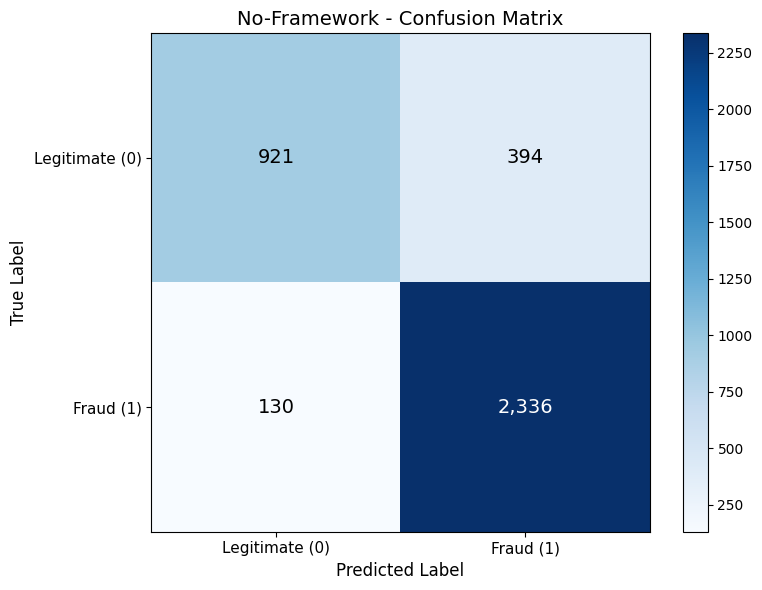

[2/4] ROC curve...


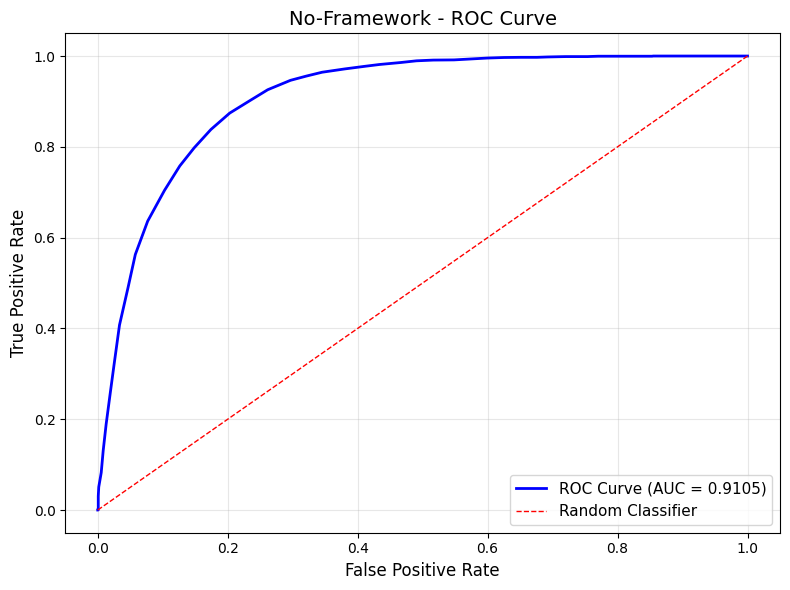

[3/4] Calibration curve...


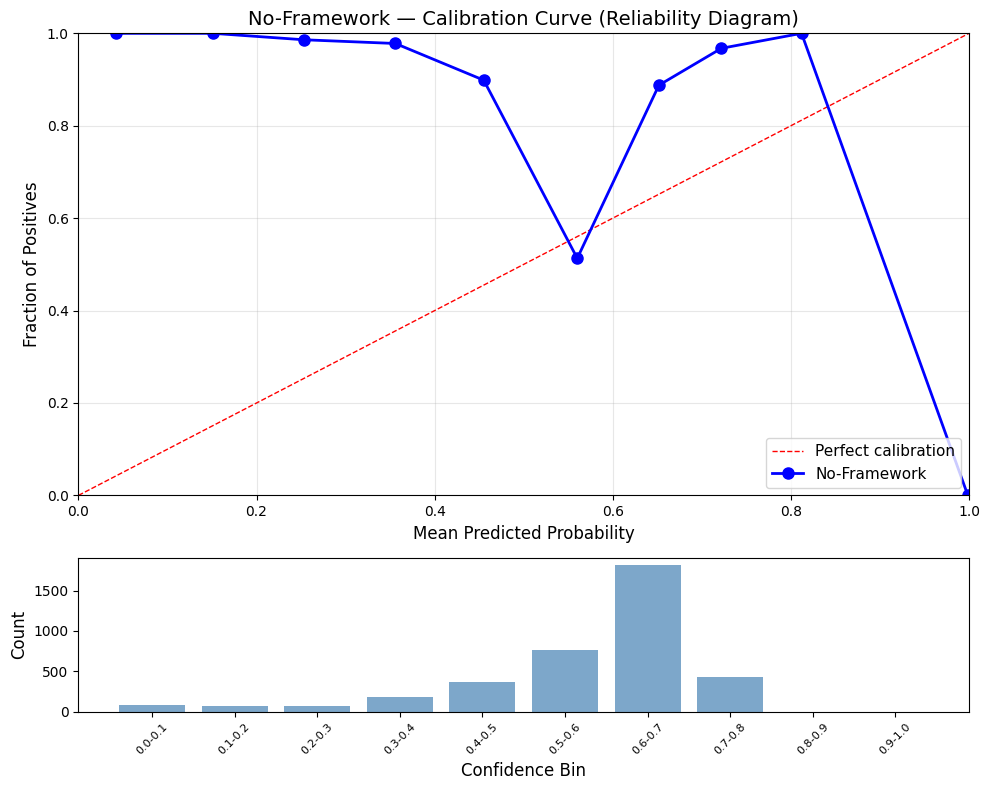

[4/4] Convergence plot...


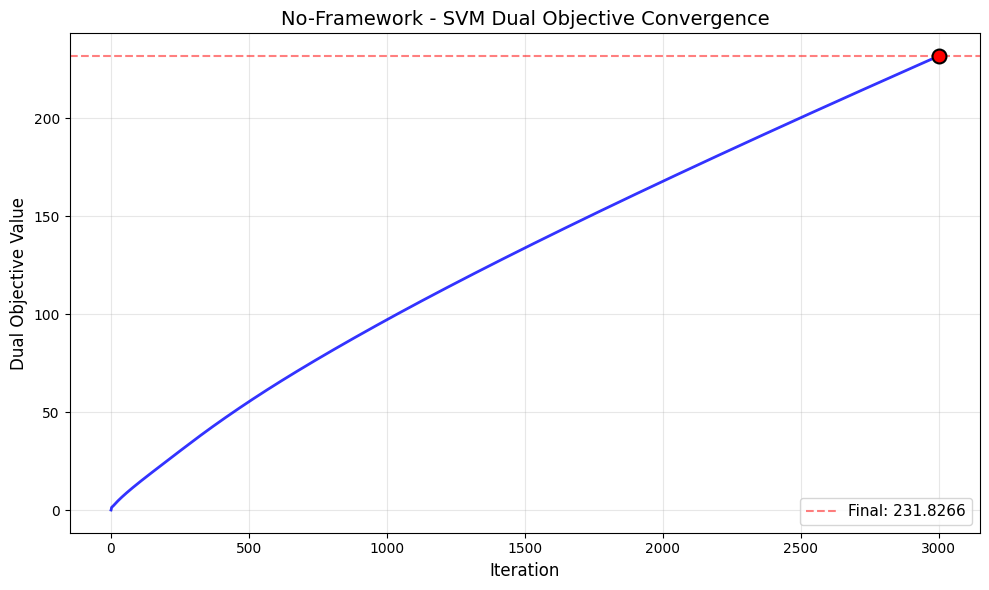


All visualizations saved to results/


In [6]:
# Step 5: Visualizations

print("=" * 60)
print("STEP 5: VISUALIZATIONS")
print("=" * 60)

# 1. Confusion Matrix
print("\n[1/4] Confusion matrix...")
plot_confusion_matrix(y_test, preds_std, FRAMEWORK,
                      save_path=f"{RESULTS_DIR}/confusion_matrix.png")

# 2. ROC Curve
print("[2/4] ROC curve...")
plot_roc_curve(y_test, probas, FRAMEWORK,
               save_path=f"{RESULTS_DIR}/roc_curve.png")

# 3. Calibration Curve
print("[3/4] Calibration curve...")
plot_calibration_curve(y_test, probas, FRAMEWORK,
                       save_path=f"{RESULTS_DIR}/calibration_curve.png")

# 4. Convergence Plot (dual objective over training iterations)
# Since we use gradient ascent on the dual (not SMO), we can track
# how the objective climbs toward the optimum each iteration
print("[4/4] Convergence plot...")
plot_svm_convergence(obj_history, FRAMEWORK,
                     save_path=f"{RESULTS_DIR}/svm_convergence.png")

print("\nAll visualizations saved to results/")

STEP 6: KERNEL COMPARISON SHOWCASE

────────────────────────────────────────
Kernel: Linear
────────────────────────────────────────
  Computing kernel matrix...
  Training (3000 iterations)...
  Accuracy: 0.6213
  F1:       0.7081
  AUC:      0.6262
  Time:     160.7s
  SVs:      14,949

────────────────────────────────────────
Kernel: RBF
────────────────────────────────────────
  Computing kernel matrix...
  Training (3000 iterations)...
  Accuracy: 0.8704
  F1:       0.9045
  AUC:      0.9212
  Time:     160.4s
  SVs:      13,418

────────────────────────────────────────
Kernel: Polynomial
────────────────────────────────────────
  Computing kernel matrix...
  Training (3000 iterations)...
  Accuracy: 0.8614
  F1:       0.8992
  AUC:      0.9105
  Time:     160.1s
  SVs:      11,426

KERNEL COMPARISON SUMMARY
  Kernel            Acc       F1      AUC     Time      SVs
  ────────────  ───────  ───────  ───────  ───────  ───────
  Linear         0.6213   0.7081   0.6262   160.7s  14,

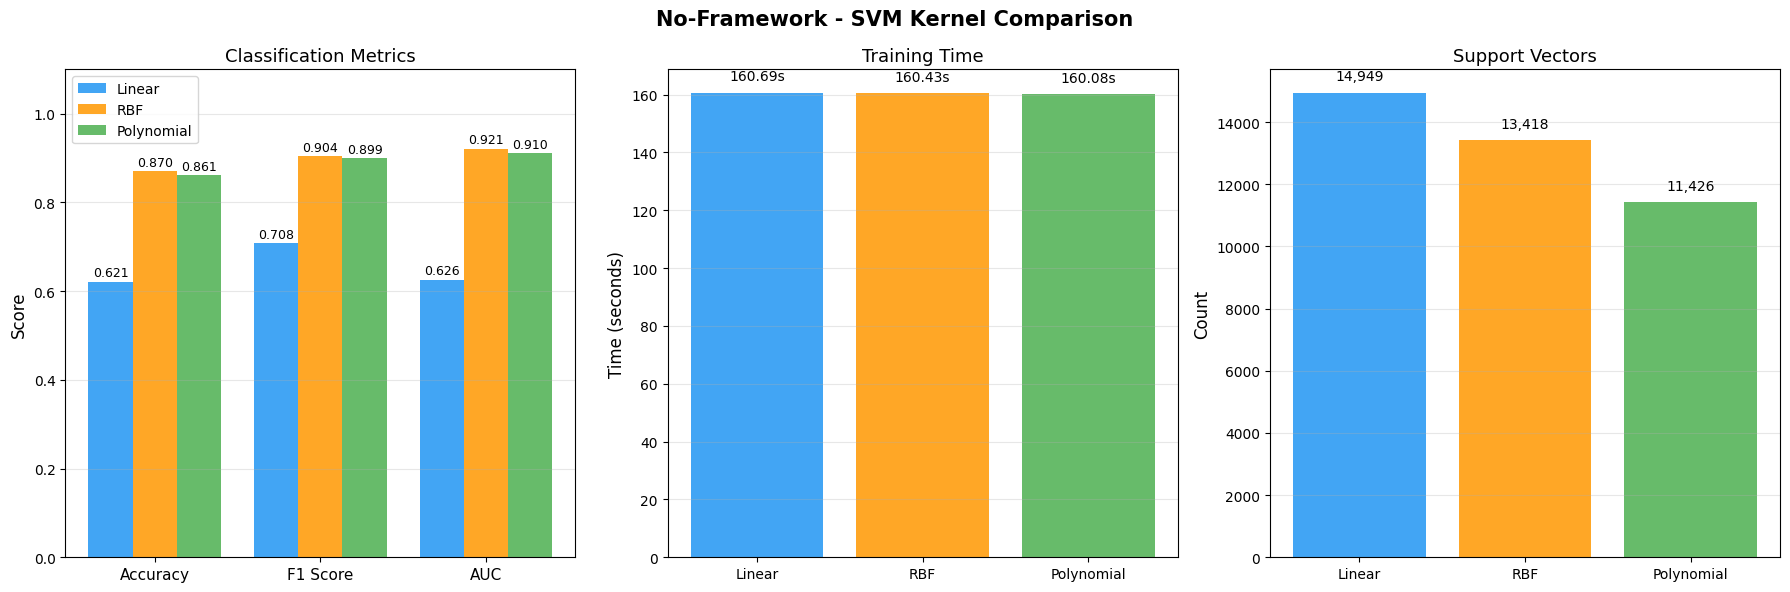


Kernel comparison plot saved.


In [7]:
# Step 6: Kernel Comparison Showcase

print("=" * 60)
print("STEP 6: KERNEL COMPARISON SHOWCASE")
print("=" * 60)

"""
Train SVMs with 3 different kernels on the same dataset.
Each kernel implicitly maps features to a different space:
  - Linear: no transformation (straight decision boundary)
  - RBF: infinite-dimensional space (flexible, localized boundaries)
  - Polynomial: degree-d interaction space (curved boundaries)

We compare accuracy, F1, AUC, training time, and support vector count.
Same hyperparameters (C=10, gamma='scale') across all kernels for fair comparison.
"""

np.random.seed(RANDOM_STATE)

# Free the Cell 6 kernel matrix — we'll compute fresh ones per kernel
del K_train

kernel_configs = {
    'Linear': {
        'fn': linear_kernel,
        'params': {},
    },
    'RBF': {
        'fn': rbf_kernel,
        'params': {'gamma': GAMMA},
    },
    'Polynomial': {
        'fn': poly_kernel,
        'params': {'gamma': GAMMA, 'degree': DEGREE, 'coef0': COEF0},
    }
}

kernel_results = {}

for name, config in kernel_configs.items():
    print(f"\n{'─' * 40}")
    print(f"Kernel: {name}")
    print(f"{'─' * 40}")

    # 1. Compute kernel matrix
    print(f"  Computing kernel matrix...")
    K = config['fn'](X_train, X_train, **config['params'])

    # 2. Train via dual gradient descent
    print(f"  Training (3000 iterations)...")
    with track_performance() as perf_k:
        alphas_k, b_k, _ = train_dual_svm(
            K, y_train_svm, C=C, n_iters=3000, verbose=False
        )

    # 3. Predict on train set (for Platt calibration)
    train_preds_k, train_dv_k = predict_svm(
        X_train, X_train, y_train_svm, alphas_k, b_k,
        config['fn'], **config['params']
    )

    # 4. Predict on test set
    preds_k, dv_k = predict_svm(
        X_test, X_train, y_train_svm, alphas_k, b_k,
        config['fn'], **config['params']
    )
    preds_k_std = to_std_labels(preds_k)

    # 5. Platt calibration for probability metrics
    A_k, B_k = platt_calibrate(train_dv_k, y_train)
    probas_k = platt_predict_proba(dv_k, A_k, B_k)

    # 6. Evaluate
    metrics_k = evaluate_classifier(y_test, preds_k_std, probas_k)
    n_sv = int(np.sum(alphas_k > 1e-5))

    kernel_results[name] = {
        'accuracy': metrics_k['accuracy'],
        'f1': metrics_k['f1'],
        'auc': metrics_k['auc'],
        'training_time': perf_k['time'],
        'n_support_vectors': n_sv
    }

    print(f"  Accuracy: {metrics_k['accuracy']:.4f}")
    print(f"  F1:       {metrics_k['f1']:.4f}")
    print(f"  AUC:      {metrics_k['auc']:.4f}")
    print(f"  Time:     {perf_k['time']:.1f}s")
    print(f"  SVs:      {n_sv:,}")

    # Free kernel matrix memory before next kernel (~1.7 GB each)
    del K

# Summary table
print(f"\n{'=' * 60}")
print("KERNEL COMPARISON SUMMARY")
print(f"{'=' * 60}")
print(f"  {'Kernel':12s}  {'Acc':>7s}  {'F1':>7s}  {'AUC':>7s}  {'Time':>7s}  {'SVs':>7s}")
print(f"  {'─'*12}  {'─'*7}  {'─'*7}  {'─'*7}  {'─'*7}  {'─'*7}")
for name, res in kernel_results.items():
    print(f"  {name:12s}  {res['accuracy']:7.4f}  {res['f1']:7.4f}  "
          f"{res['auc']:7.4f}  {res['training_time']:6.1f}s  "
          f"{res['n_support_vectors']:>6,}")

# Visualization
plot_kernel_comparison(kernel_results, FRAMEWORK,
                       save_path=f"{RESULTS_DIR}/kernel_comparison.png")
print("\nKernel comparison plot saved.")

In [8]:
# Step 7: Inference Benchmarks + Model Size

print("=" * 60)
print("STEP 7: INFERENCE & MODEL SIZE")
print("=" * 60)

# Predict wrapper: track_inference expects predict_fn(X) callable,
# so we wrap predict_svm in a closure that captures the trained model
sv_mask = alphas > 1e-5

def predict_wrapper(X_new):
    preds, _ = predict_svm(X_new, X_train, y_train_svm, alphas, b,
                            poly_kernel, gamma=GAMMA, degree=DEGREE, coef0=COEF0)
    return to_std_labels(preds)

# Benchmark: 100 timed runs (1 warmup excluded)
print("\n[1/3] Inference benchmarks (100 runs)...")
inference_stats = track_inference(predict_wrapper, X_test, n_runs=100)

print(f"  Avg batch time:      {inference_stats['total_time']*1000:.2f} ms")
print(f"  Per-sample:          {inference_stats['per_sample_us']:.2f} µs")
print(f"  Throughput:          {inference_stats['samples_per_sec']:,.0f} samples/sec")

# Model size: only the components needed for prediction
# (support vectors, their alphas, their labels, and bias)
print("\n[2/3] Model size...")
model_dict = {
    'support_vectors': X_train[sv_mask],
    'sv_alphas': alphas[sv_mask],
    'sv_labels': y_train_svm[sv_mask],
    'bias': np.array([b])
}
model_size = get_model_size(model_dict, framework='numpy')

n_sv = int(np.sum(sv_mask))
print(f"  Support vectors: {n_sv:,} / {X_train.shape[0]:,}")
print(f"  In-memory size:  {model_size / 1024:.1f} KB ({model_size / (1024**2):.2f} MB)")

# Save model via pickle for serialized size
print("\n[3/3] Saving model...")
with open(f'{RESULTS_DIR}/svm_model.pkl', 'wb') as f:
    pickle.dump(model_dict, f)
file_size = os.path.getsize(f'{RESULTS_DIR}/svm_model.pkl')
print(f"  Saved to: {RESULTS_DIR}/svm_model.pkl")
print(f"  File size: {file_size / 1024:.1f} KB ({file_size / (1024**2):.2f} MB)")

STEP 7: INFERENCE & MODEL SIZE

[1/3] Inference benchmarks (100 runs)...
  Avg batch time:      580.65 ms
  Per-sample:          153.57 µs
  Throughput:          6,512 samples/sec

[2/3] Model size...
  Support vectors: 11,426 / 15,124
  In-memory size:  1071.2 KB (1.05 MB)

[3/3] Saving model...
  Saved to: results/svm_model.pkl
  File size: 1071.6 KB (1.05 MB)


In [9]:
# Step 8: Save Results + Cross-Framework Comparison

print("=" * 60)
print("STEP 8: SAVE RESULTS")
print("=" * 60)

results = build_results_dict(
    framework=FRAMEWORK,
    model_name='SVM',
    test_metrics=test_metrics,
    perf=perf,
    inference_stats=inference_stats,
    model_size=model_size,
    kernel='poly',
    C=C,
    degree=DEGREE,
    n_support_vectors=int(np.sum(alphas > 1e-5))
)

# Save locally to results/metrics.json
save_results(results, save_dir=RESULTS_DIR)

# Add to cross-framework comparison file
add_result('svm', results)

# Print comparison table
print_comparison('svm')

STEP 8: SAVE RESULTS
    Results saved to: results\metrics.json
    Added 'No-Framework' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\svm.json
    Frameworks recorded: 2/4

CROSS-FRAMEWORK COMPARISON: SVM
Metric                          Scikit-Learn  No-Framework
----------------------------------------------------------
model                                    SVM           SVM
training_time                        20.32 s       2.7 min
inference_time_per_sample_us        36.63 µs     153.57 µs
model_size_bytes                    523.4 KB       1.05 MB
peak_memory_mb                       1.30 MB       1.29 GB
accuracy                              0.8606        0.8614
precision                             0.8855        0.8557
recall                                0.9031        0.9473
f1                                    0.8942        0.8992
auc                                   0.9164        0.9105
log_loss                              0.3486    